# Hermle JSON → CSV Conversion

Converts the MongoDB-exported `*.processed.json` files in `data/Hermle/<yyyymmdd>/` into per-sample CSV files in `data/converted/<yyyymmdd>/`.

Each JSON file is a list of measurement **records** (one per batch). A record carries a handful of scalar fields (id, timestamp, acceleration stats) plus several sensor arrays that all share the same length within a record (200 or 1000 samples, depending on the file), and a `prediction` field whose entries are themselves 9-value lists.

This notebook builds the conversion up step by step:
1. Inspect one source file to understand the schema
2. Define and test a function that flattens a single record into long-format rows
3. Wrap it to convert one whole file
4. Run it over every JSON file in the input folder
5. Verify the written CSVs against the source JSON

In [4]:
import re
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

## 1 · Inspect one source file

Before writing any conversion code, load the first JSON file in the input folder and look at its raw structure: how many records it has, what fields a record contains, and which fields are arrays vs. plain scalars.

In [5]:
input_dir = Path("../data/Hermle/20260623")

json_files = sorted(input_dir.glob("*.json"))
print(f"Found {len(json_files)} JSON file(s) in {input_dir}:")
for p in json_files:
    print(f"  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")

with open(json_files[0]) as f:
    sample_data = json.load(f)

record = sample_data[0]
print(f"\n{json_files[0].name}: {len(sample_data)} records")
print("\nFields in the first record:")
for key, value in record.items():
    if isinstance(value, list):
        inner = f", inner_len={len(value[0])}" if value and isinstance(value[0], list) else ""
        print(f"  {key:28s} list, len={len(value)}{inner}")
    else:
        print(f"  {key:28s} {type(value).__name__} = {value}")

Found 7 JSON file(s) in ..\data\Hermle\20260623:
  2026_06_23_AE_Kraftmessung_rdf_01.processed.json  (3.7 MB)
  2026_06_23_AE_Kraftmessung_rdf_02.processed.json  (15.9 MB)
  2026_06_23_AE_Kraftmessung_rdf_03.processed.json  (17.9 MB)
  2026_06_23_AE_Kraftmessung_rdf_04.processed.json  (7.9 MB)
  2026_06_23_AE_Kraftmessung_rdf_05.processed.json  (7.9 MB)
  2026_06_23_AE_Kraftmessung_rdf_06.processed.json  (20.9 MB)
  2026_06_23_AE_Vary_rdf_01.processed.json  (2.9 MB)

2026_06_23_AE_Kraftmessung_rdf_01.processed.json: 37 records

Fields in the first record:
  _id                          dict = {'$oid': '6a3a964d2de3d3170ceb7b53'}
  time                         dict = {'$date': '2026-06-23T14:21:01.841Z'}
  axial_displacement_max       list, len=200
  axial_displacement_mean      list, len=200
  radial_displacement_max      list, len=200
  radial_displacement_mean     list, len=200
  spindle_speed                list, len=200
  temperature                  list, len=200
  prediction     

## 2 · Record schema

Every record in these files falls into one of three categories:

| Category | Fields | Shape |
|---|---|---|
| Identity | `_id` (`{"$oid": ...}`), `time` (`{"$date": ...}`) | one value per record |
| Per-record scalars | `acceleration_axial_{rms,peak}`, `acceleration_radial_{1,2}_{rms,peak}` | one value per record |
| Per-sample arrays | `spindle_speed`, `temperature`, `axial_displacement_*`, `radial_displacement_*`, and — only in the `Kraftmessung` files — `axial_force_*`, `radial_force_*` | one list of length `L` per record (`L` is 200 or 1000, consistent within a file) |
| Per-sample, multi-valued | `prediction` | a length-`L` list whose entries are themselves 9-value lists — dropped during conversion, not part of the output |

The target CSV layout is **long format**: each record becomes `L` rows (one per sample), with the identity and scalar fields repeated on every row and the per-sample arrays contributing one column each. `prediction` is dropped rather than expanded. A `record_idx` / `sample_idx` pair is added so rows can always be traced back to their source record and position within it.

## 3 · `flatten_record` — flatten one record into long-format rows

The function below:
- pulls `id` out of `_id["$oid"]` and `time` out of `time["$date"]`
- finds the sample length `L` from the first per-sample array field, and raises if any other per-sample array disagrees (so a schema surprise fails loudly instead of silently misaligning rows)
- drops the `prediction` field entirely — it is not extracted or carried into the output
- lets the per-record scalars broadcast against the `L`-length columns — `pd.DataFrame` does this automatically when at least one value in the dict is array-like, so there's no manual row-by-row construction

In [6]:
def flatten_record(record: dict, record_idx: int) -> pd.DataFrame:
    """Flatten one Hermle JSON record into `L` long-format rows (one per sample).

    The `prediction` field is intentionally dropped — it is not part of the
    converted output.
    """
    rec_id = record["_id"]["$oid"]
    time = record["time"]["$date"]

    columns = {}
    sample_len = None

    for key, value in record.items():
        if key in ("_id", "time", "prediction"):
            continue
        if isinstance(value, list):
            if sample_len is None:
                sample_len = len(value)
            elif len(value) != sample_len:
                raise ValueError(
                    f"record {record_idx}: field '{key}' has length {len(value)}, "
                    f"expected {sample_len}"
                )
            columns[key] = value
        else:
            columns[key] = value  # per-record scalar, broadcast below

    if sample_len is None:
        raise ValueError(f"record {record_idx}: no per-sample array field found")

    return pd.DataFrame({
        "id": rec_id,
        "time": time,
        "record_idx": record_idx,
        "sample_idx": np.arange(sample_len),
        **columns,
    })

## 4 · Test on a single record

Run `flatten_record` on the first record of the sample file loaded in step 1 and check the shape and first rows before scaling up to a whole file.

In [7]:
test_df = flatten_record(record, record_idx=0)
print(f"shape: {test_df.shape}")
test_df.head()

shape: (200, 20)


,id,time,record_idx,sample_idx,axial_displacement_max,axial_displacement_mean,radial_displacement_max,radial_displacement_mean,spindle_speed,temperature,acceleration_axial_rms,acceleration_axial_peak,acceleration_radial_1_rms,acceleration_radial_1_peak,acceleration_radial_2_rms,acceleration_radial_2_peak,axial_force_max,axial_force_mean,radial_force_max,radial_force_mean
0,6a3a964d2de3d3170ceb7b53,2026-06-23T14:21:01.841Z,0,0,-0.065709,-0.070427,0.003935,0.003785,3232.383789,59.297497,22.593609,33,4.610583,16,0,0,0.013959,-0.035900,0.103620,0.048202
1,6a3a964d2de3d3170ceb7b53,2026-06-23T14:21:01.841Z,0,1,-0.070026,-0.071983,0.003532,0.003302,3231.757621,59.297497,22.593609,33,4.610583,16,0,0,0.040185,-0.024965,0.144324,0.055232
2,6a3a964d2de3d3170ceb7b53,2026-06-23T14:21:01.841Z,0,2,-0.064021,-0.070488,0.003215,0.003034,3232.380442,59.297497,22.593609,33,4.610583,16,0,0,0.032566,-0.021755,0.114647,0.047106
3,6a3a964d2de3d3170ceb7b53,2026-06-23T14:21:01.841Z,0,3,-0.069225,-0.071508,0.002799,0.002630,3232.210361,59.297497,22.593609,33,4.610583,16,0,0,0.010343,-0.016920,0.153282,0.059903
4,6a3a964d2de3d3170ceb7b53,2026-06-23T14:21:01.841Z,0,4,-0.053274,-0.069692,0.002605,0.002404,3231.535436,59.297497,22.593609,33,4.610583,16,0,0,0.022411,-0.022368,0.116053,0.060909


## 5 · `convert_file` — convert one whole JSON file

Loads every record from a file, flattens each with `flatten_record`, and concatenates them into a single DataFrame.

In [8]:
def convert_file(json_path: Path) -> pd.DataFrame:
    """Load a Hermle *.processed.json file and return it as one long-format DataFrame."""
    with open(json_path) as f:
        records = json.load(f)
    frames = [flatten_record(rec, idx) for idx, rec in enumerate(records)]
    return pd.concat(frames, ignore_index=True)


test_file_df = convert_file(json_files[0])
print(
    f"{json_files[0].name}: {len(sample_data)} records "
    f"-> {test_file_df.shape[0]} rows, {test_file_df.shape[1]} columns"
)
test_file_df.columns.tolist()

2026_06_23_AE_Kraftmessung_rdf_01.processed.json: 37 records -> 7400 rows, 20 columns


['id',
 'time',
 'record_idx',
 'sample_idx',
 'axial_displacement_max',
 'axial_displacement_mean',
 'radial_displacement_max',
 'radial_displacement_mean',
 'spindle_speed',
 'temperature',
 'acceleration_axial_rms',
 'acceleration_axial_peak',
 'acceleration_radial_1_rms',
 'acceleration_radial_1_peak',
 'acceleration_radial_2_rms',
 'acceleration_radial_2_peak',
 'axial_force_max',
 'axial_force_mean',
 'radial_force_max',
 'radial_force_mean']

## 6 · `add_time_calc` — recover a real per-sample time axis

Within a record, every sample row carries the exact same `time` value (the record's timestamp, broadcast in step 3). Across records `time` only changes once per `L` samples, so over a whole file the column looks like a staircase rather than a smooth clock — many consecutive rows share the exact same timestamp.

`add_time_calc` turns that staircase into a believable per-sample time axis: for each run of repeated `time` values, the gap to the *next* run's value is divided by the run's length to get a constant step, and the repeated values are replaced by points spaced by that step (the trailing run, which has no later timestamp to interpolate towards, reuses the previous run's step). The whole series is then shifted so the first sample sits at `0`.

In [9]:
def add_time_calc(df: pd.DataFrame) -> pd.DataFrame:
    """Add `time_calc`: seconds elapsed since the first sample, with the per-record
    `time` staircase interpolated into a strictly increasing per-sample axis."""
    t = pd.to_datetime(df["time"]).to_numpy(dtype="datetime64[ns]").astype("int64") / 1e9

    is_run_start = np.empty(len(t), dtype=bool)
    is_run_start[0] = True
    is_run_start[1:] = t[1:] != t[:-1]
    run_id = np.cumsum(is_run_start) - 1

    run_starts = np.flatnonzero(is_run_start)
    run_values = t[run_starts]
    run_lengths = np.diff(np.append(run_starts, len(t)))

    step = np.empty(len(run_values))
    step[:-1] = np.diff(run_values) / run_lengths[:-1]
    step[-1] = step[-2] if len(step) > 1 else 0.0

    within_run_idx = np.arange(len(t)) - run_starts[run_id]
    time_calc = run_values[run_id] + within_run_idx * step[run_id]

    return df.assign(time_calc=time_calc - time_calc[0])


test_file_df = add_time_calc(test_file_df)

assert test_file_df["time_calc"].iloc[0] == 0
assert test_file_df["time_calc"].is_monotonic_increasing

first_record = test_file_df[test_file_df["record_idx"] == 0]
second_record_time = test_file_df.loc[test_file_df["record_idx"] == 1, "time"].iloc[0]
expected_step = (
    pd.Timestamp(second_record_time) - pd.Timestamp(first_record["time"].iloc[0])
).total_seconds() / len(first_record)
actual_step = first_record["time_calc"].diff().dropna().iloc[0]
assert np.isclose(actual_step, expected_step)

test_file_df[["record_idx", "sample_idx", "time", "time_calc"]].head(3)

,record_idx,sample_idx,time,time_calc
0,0,0,2026-06-23T14:21:01.841Z,0.000000
1,0,1,2026-06-23T14:21:01.841Z,0.050705
2,0,2,2026-06-23T14:21:01.841Z,0.101410


## 7 · Output folder

The output folder mirrors the input folder's date: if `input_dir`'s name is a `yyyymmdd` string, the same date is reused under `data/converted/`; otherwise today's date is used. This keeps a 1:1 mapping between an input batch folder and its converted output without hardcoding the date.

In [10]:
if re.fullmatch(r"\d{8}", input_dir.name):
    date_str = input_dir.name
else:
    date_str = datetime.now().strftime("%Y%m%d")

output_dir = Path("../data/converted") / date_str
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output folder: {output_dir.resolve()}")

Output folder: C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260623


## 8 · Convert every file in the folder

Runs `convert_file` over every `*.json` file in `input_dir`, adds `time_calc` with `add_time_calc`, then splits each file's rows by `record_idx` and writes **one CSV per record**, named `<stem>_<record_idx>.csv` with the record index zero-padded to two digits (so `*.processed.json` record `0` becomes `*.processed_00.csv`, record `10` becomes `*.processed_10.csv`, etc.).

In [11]:
written = []
for json_path in json_files:
    df = convert_file(json_path)
    df = add_time_calc(df)
    record_paths = []
    for record_idx, record_df in df.groupby("record_idx"):
        out_path = output_dir / f"{json_path.stem}_{record_idx:02d}.csv"
        record_df.to_csv(out_path, index=False)
        record_paths.append(out_path)
    written.extend(record_paths)
    print(
        f"{json_path.name:55s} -> {len(record_paths):3d} CSV file(s) "
        f"({record_paths[0].name} .. {record_paths[-1].name}), "
        f"{df.shape[0]:6d} rows total, {df.shape[1]:2d} cols"
    )

2026_06_23_AE_Kraftmessung_rdf_01.processed.json        ->  37 CSV file(s) (2026_06_23_AE_Kraftmessung_rdf_01.processed_00.csv .. 2026_06_23_AE_Kraftmessung_rdf_01.processed_36.csv),   7400 rows total, 21 cols
2026_06_23_AE_Kraftmessung_rdf_02.processed.json        ->  32 CSV file(s) (2026_06_23_AE_Kraftmessung_rdf_02.processed_00.csv .. 2026_06_23_AE_Kraftmessung_rdf_02.processed_31.csv),  32000 rows total, 21 cols
2026_06_23_AE_Kraftmessung_rdf_03.processed.json        ->  36 CSV file(s) (2026_06_23_AE_Kraftmessung_rdf_03.processed_00.csv .. 2026_06_23_AE_Kraftmessung_rdf_03.processed_35.csv),  36000 rows total, 21 cols
2026_06_23_AE_Kraftmessung_rdf_04.processed.json        ->  16 CSV file(s) (2026_06_23_AE_Kraftmessung_rdf_04.processed_00.csv .. 2026_06_23_AE_Kraftmessung_rdf_04.processed_15.csv),  16000 rows total, 21 cols
2026_06_23_AE_Kraftmessung_rdf_05.processed.json        ->  16 CSV file(s) (2026_06_23_AE_Kraftmessung_rdf_05.processed_00.csv .. 2026_06_23_AE_Kraftmessung_rdf

## 9 · Verify the results

Lists how many per-record CSVs were written and spot-checks a couple of values from the first and last record of the first file against the original JSON to confirm nothing got misaligned during the flatten/split steps, then checks that `time_calc` is a real strictly-increasing time axis starting at `0`.

In [16]:
total_size = sum(p.stat().st_size for p in written)
print(f"{len(written)} CSV file(s) in {output_dir} (total {total_size / 1e6:.1f} MB)")
for p in sorted(output_dir.iterdir())[:5]:
    print(f"  {p.name}  ({p.stat().st_size / 1e6:.2f} MB)")
print("  ...")

check_df = pd.read_csv(written[0])

# np.isclose, not ==, because writing to CSV and reading back loses a few
# bits of float precision (text round-trip), not a sign of a real mismatch
assert np.isclose(check_df.loc[0, "spindle_speed"], sample_data[0]["spindle_speed"][0])
assert check_df.loc[0, "id"] == sample_data[0]["_id"]["$oid"]
assert "prediction" not in check_df.columns and not any(
    c.startswith("prediction_") for c in check_df.columns
)

last_record_idx = len(sample_data) - 1
last_record_path = output_dir / f"{json_files[0].stem}_{last_record_idx:02d}.csv"
last_record_df = pd.read_csv(last_record_path)
assert np.isclose(last_record_df.loc[0, "temperature"], sample_data[-1]["temperature"][0])

assert check_df["time_calc"].iloc[0] == 0
assert check_df["time_calc"].is_monotonic_increasing

print("Spot checks passed: values in the written CSVs match the source JSON.")

215 CSV file(s) in ..\data\converted\20260623 (total 49.6 MB)
  2026_06_23_AE_Kraftmessung_rdf_01.processed_00.csv  (0.06 MB)
  2026_06_23_AE_Kraftmessung_rdf_01.processed_01.csv  (0.06 MB)
  2026_06_23_AE_Kraftmessung_rdf_01.processed_02.csv  (0.06 MB)
  2026_06_23_AE_Kraftmessung_rdf_01.processed_03.csv  (0.06 MB)
  2026_06_23_AE_Kraftmessung_rdf_01.processed_04.csv  (0.06 MB)
  ...
Spot checks passed: values in the written CSVs match the source JSON.


In [20]:
# Read the first record's CSV for rdf_06
file_idx = 2
rdf_06_csvs = sorted(output_dir.glob(f"{json_files[5].stem}_*.csv"))
df_kraftmessung = pd.read_csv(rdf_06_csvs[file_idx])

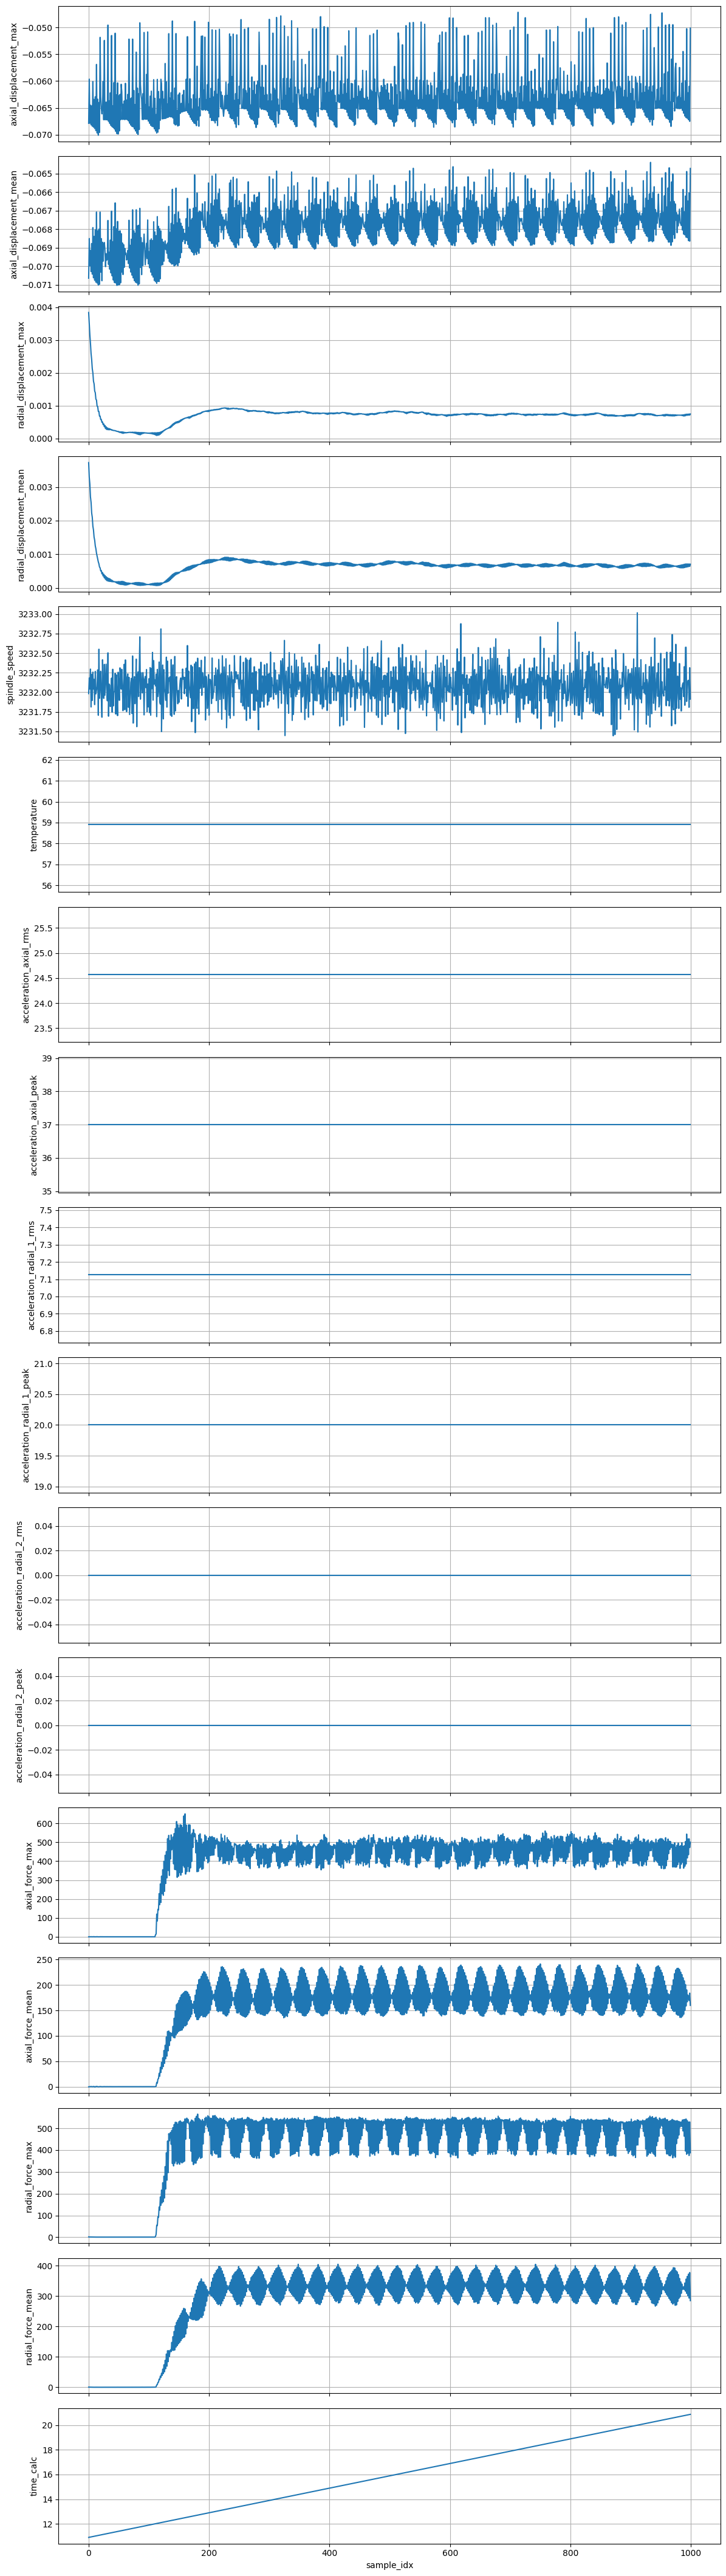

In [ ]:
import matplotlib.pyplot as plt

# First record's CSV for rdf_06 (change the index into rdf_06_csvs for a different record)
rdf_06_csvs = sorted(output_dir.glob(f"{json_files[5].stem}_*.csv"))
df6 = pd.read_csv(rdf_06_csvs[file_idx])
rec = df6

# numeric signals except the index columns
signals = rec.select_dtypes(include=[np.number]).columns.drop(["record_idx", "sample_idx"])

fig, axes = plt.subplots(len(signals), 1, figsize=(12, 2.5 * len(signals)), sharex=True)
if len(signals) == 1:
    axes = [axes]

for ax, col in zip(axes, signals):
    ax.plot(rec["sample_idx"], rec[col])
    ax.set_ylabel(col)
    ax.grid(True)

axes[-1].set_xlabel("sample_idx")
plt.tight_layout()
plt.show()